# Image to Images

In [57]:
from PIL import Image

img = Image.open("macbook.jpeg")
img.show()

In [58]:
image_files = ["macbook.jpeg", "macbook_.jpeg", "earbuds.jpeg", "earbuds_.jpeg", "iphone.jpg", "samsung.jpeg"]

for file in image_files:
    img = Image.open(file)
    print(file, img.size)
    img.show()

macbook.jpeg (563, 355)
macbook_.jpeg (594, 336)
earbuds.jpeg (225, 225)
earbuds_.jpeg (416, 480)
iphone.jpg (975, 1300)
samsung.jpeg (480, 638)


# Imagelarni tartiblash

In [16]:
import os

folders = [
    "dataset/train/laptops",
    "dataset/train/phones",
    "dataset/train/earbuds",
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Folders created successfully.")

Folders created successfully.


In [17]:
import os
import shutil

files_to_copy = {
    "macbook.jpeg": "dataset/train/laptops/macbook.jpeg",
    "macbook_.jpeg": "dataset/train/laptops/macbook_.jpeg",
    "earbuds.jpeg": "dataset/train/earbuds/earbuds.jpeg",
    "earbuds_.jpeg": "dataset/train/earbuds/earbuds_.jpeg",
    "samsung.jpeg": "dataset/train/phones/samsung.jpeg",
    "iphone.jpg": "dataset/train/phones/iphone.jpg"

}

for src, dst in files_to_copy.items():
    shutil.copy(src, dst)

print("Images copied successfully.")

Images copied successfully.


In [18]:
import os

train_path = "dataset/train"

classes = os.listdir(train_path)

print("Classes found:", classes)

Classes found: ['laptops', 'phones', 'earbuds']


# Preprocessing= Transforms

In [29]:
from torchvision.datasets import ImageFolder

data = ImageFolder("dataset/train")

image_file, label = data.samples[0]   # (yo'l, label) juftligi
img, _ = data[0]                      # shu rasmning o'zi (PIL Image)

print("Original image:", image_file)
print("Original size:", img.size)
print("Label:", label, "->", data.classes[label])

resized_img = img.resize((128, 128))
print("Resized size:", resized_img.size)

resized_img.show()

Original image: dataset/train/earbuds/earbuds.jpeg
Original size: (225, 225)
Label: 0 -> earbuds
Resized size: (128, 128)


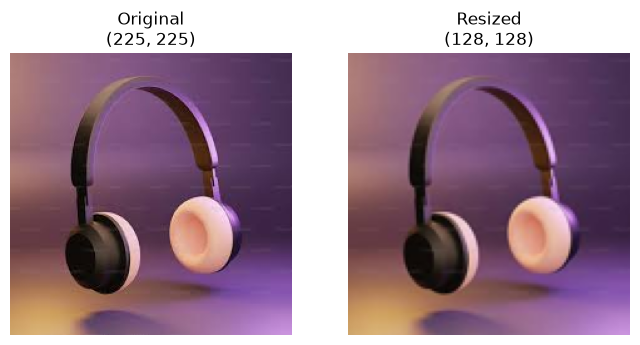

In [30]:

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title(f"Original\n{img.size}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(resized_img)
plt.title(f"Resized\n{resized_img.size}")
plt.axis("off")

plt.show()


Original size: (225, 225)
Cropped size: (150, 120)


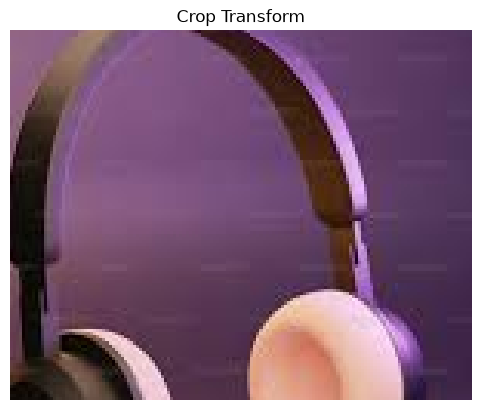

In [31]:
# Crop
cropped_img = img.crop((50, 30, 200, 150))
# (left, top, right, bottom)

print("Original size:", img.size)
print("Cropped size:", cropped_img.size)

plt.imshow(cropped_img)
plt.title("Crop Transform")
plt.axis("off")
plt.show()

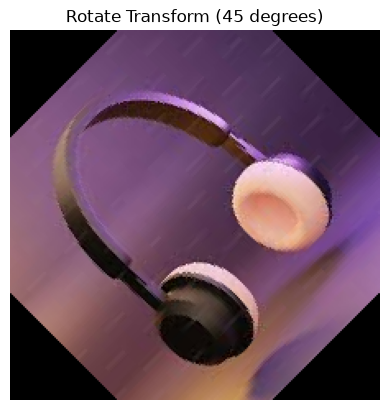

In [32]:
# rotate
rotated_img = img.rotate(45)

plt.imshow(rotated_img)
plt.title("Rotate Transform (45 degrees)")
plt.axis("off")
plt.show()

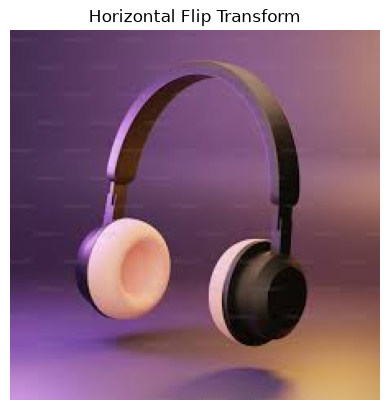

In [33]:
# Gorizantal flip
flipped_img = img.transpose(Image.FLIP_LEFT_RIGHT)

plt.imshow(flipped_img)
plt.title("Horizontal Flip Transform")
plt.axis("off")
plt.show()

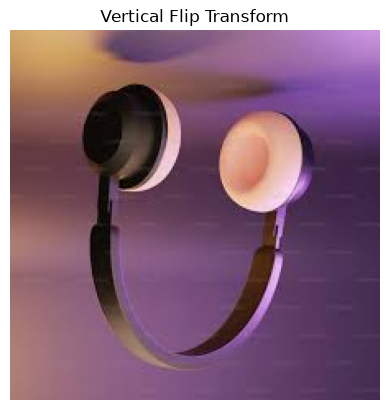

In [34]:
#Vertical
vertical_flip_img = img.transpose(Image.FLIP_TOP_BOTTOM)

plt.imshow(vertical_flip_img)
plt.title("Vertical Flip Transform")
plt.axis("off")
plt.show()

Grayscale size: (225, 225)


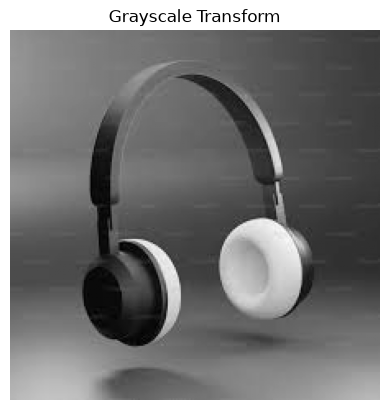

In [35]:
# Grayscale transform
gray_img = img.convert("L")

print("Grayscale size:", gray_img.size)

plt.imshow(gray_img, cmap="gray")
plt.title("Grayscale Transform")
plt.axis("off")
plt.show()

Array shape: (225, 225, 3)
Array type: <class 'numpy.ndarray'>


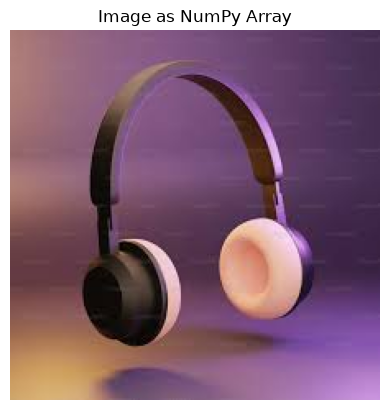

In [36]:
# RGB to numpy
import numpy as np
img_array = np.array(img)

print("Array shape:", img_array.shape)
print("Array type:", type(img_array))

plt.imshow(img_array)
plt.title("Image as NumPy Array")
plt.axis("off")
plt.show()

Min value: 0.0
Max value: 1.0
Shape: (225, 225, 3)


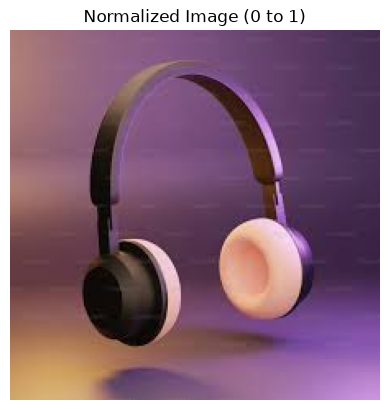

In [37]:
#Normalization
img_array = np.array(img).astype(np.float32) / 255.0

print("Min value:", img_array.min())
print("Max value:", img_array.max())
print("Shape:", img_array.shape)

plt.imshow(img_array)
plt.title("Normalized Image (0 to 1)")
plt.axis("off")
plt.show()

Final shape: (128, 128)
Min: 0.003921569
Max: 0.9098039


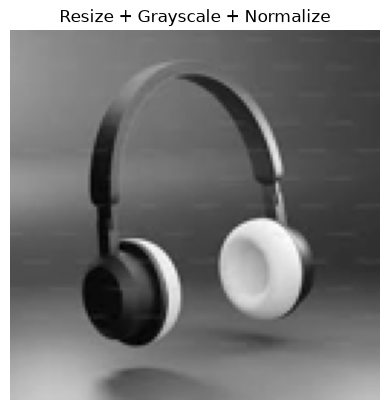

In [38]:
#Resize + Grayscale + Normalize Together
img = Image.open(image_file)

img = img.resize((128, 128))


img = img.convert("L")

img_array = np.array(img).astype(np.float32)

img_array = img_array / 255.0

print("Final shape:", img_array.shape)
print("Min:", img_array.min())
print("Max:", img_array.max())

plt.imshow(img_array, cmap="gray")
plt.title("Resize + Grayscale + Normalize")
plt.axis("off")
plt.show()

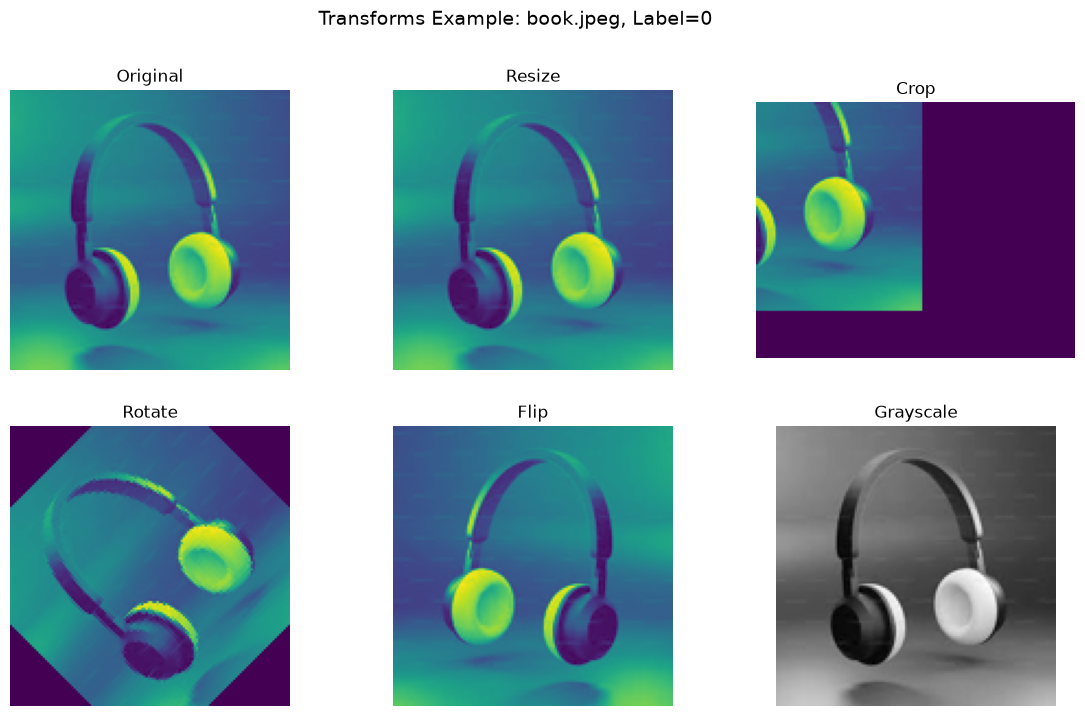

In [41]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt


resized_img = img.resize((128, 128))
cropped_img = img.crop((50, 30, 200, 150))
rotated_img = img.rotate(45)
flipped_img = img.transpose(Image.FLIP_LEFT_RIGHT)
# gray_img = img.convert("L")

plt.figure(figsize=(14, 8))

plt.subplot(2, 3, 1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(resized_img)
plt.title("Resize")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(cropped_img)
plt.title("Crop")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(rotated_img)
plt.title("Rotate")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(flipped_img)
plt.title("Flip")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(gray_img, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.suptitle(f"Transforms Example: {image_file}, Label={label}", fontsize=14)
plt.show()

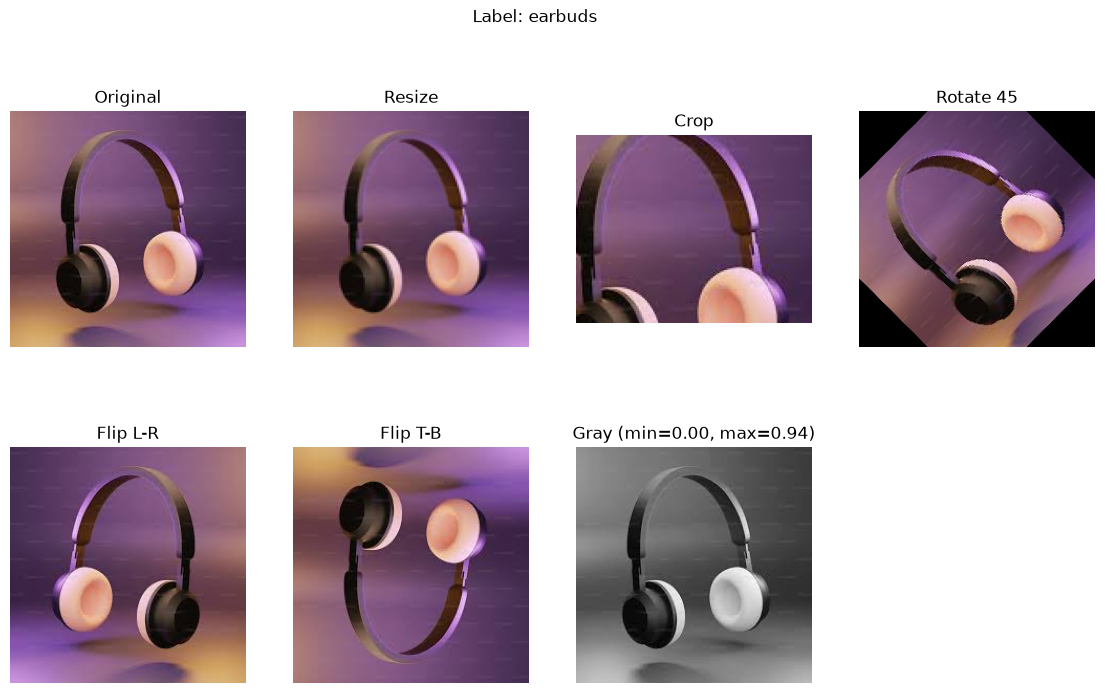

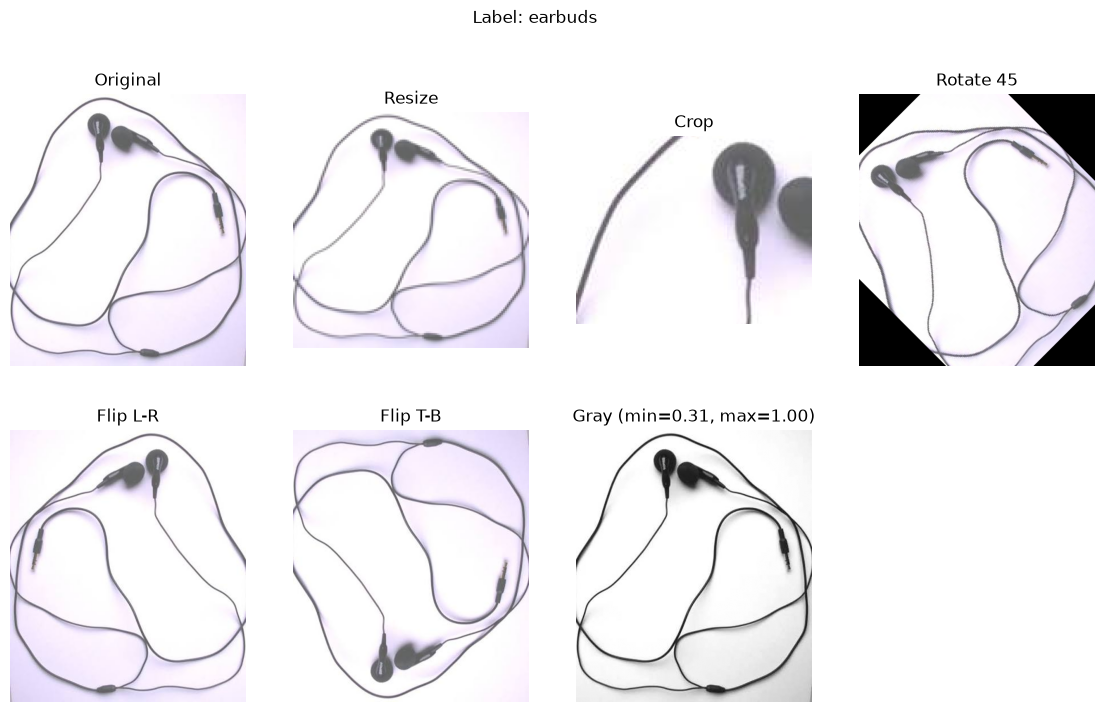

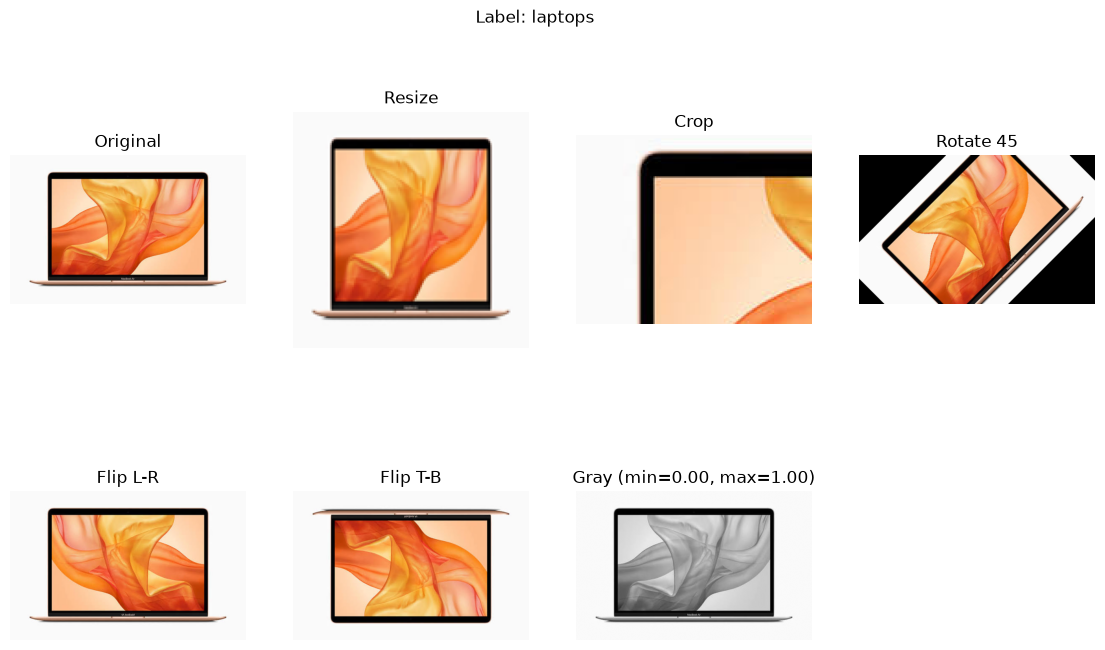

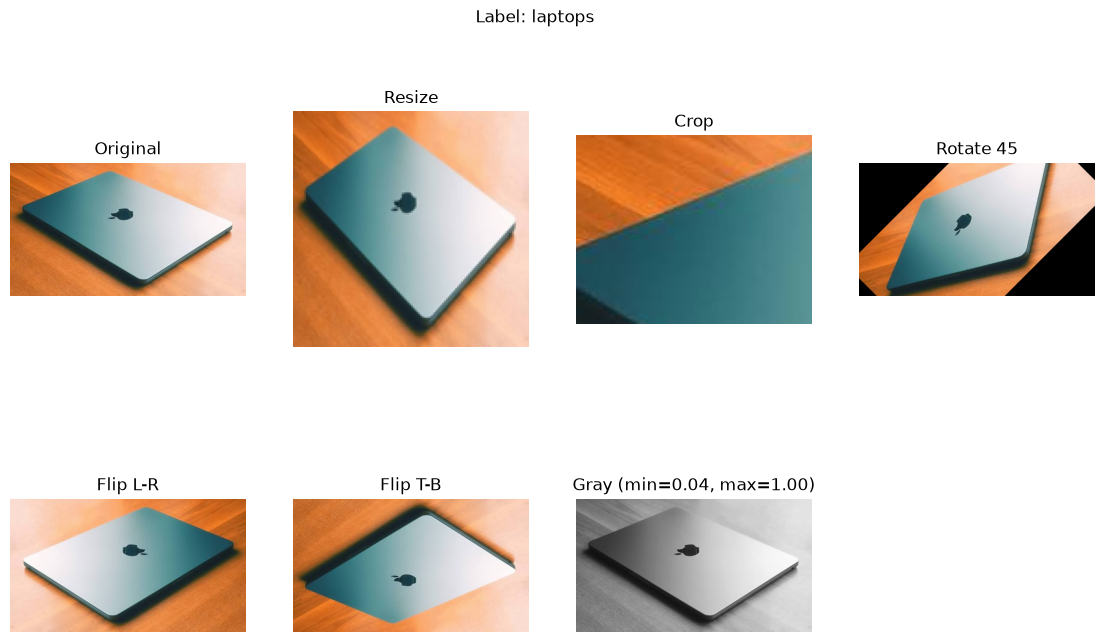

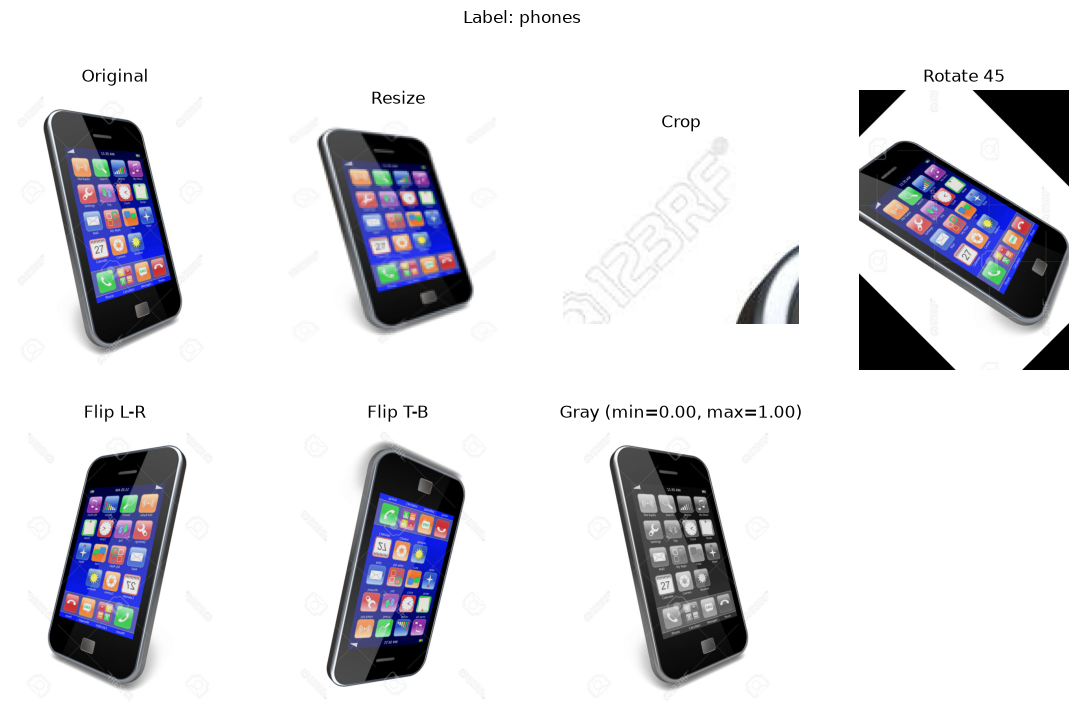

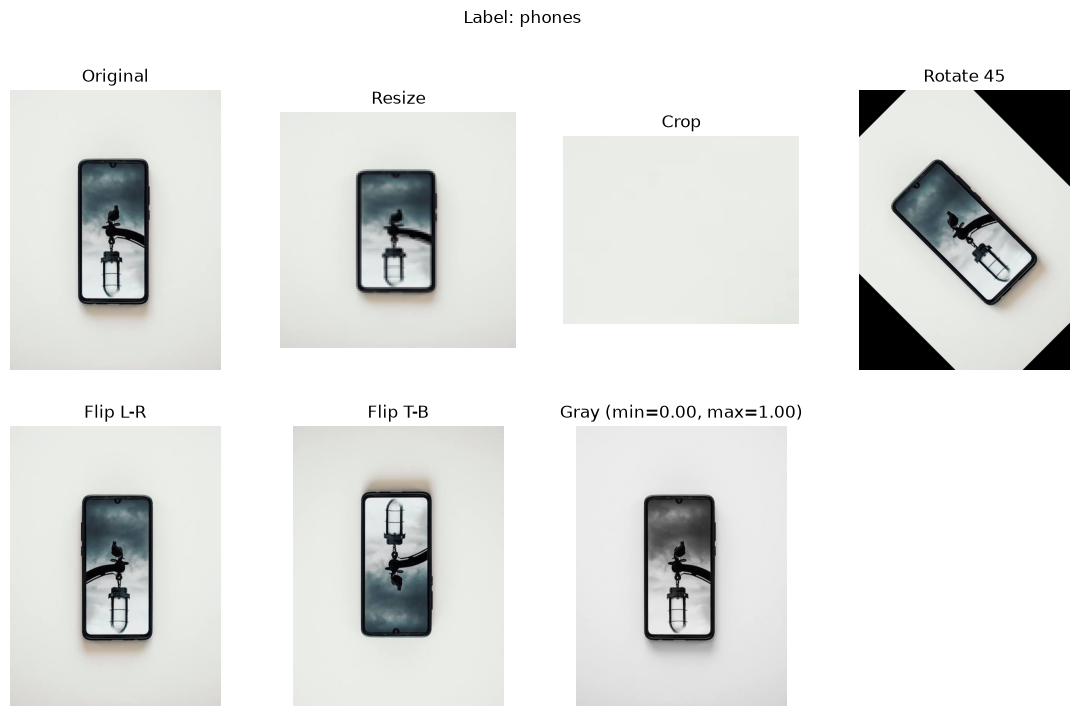

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision.datasets import ImageFolder

data = ImageFolder("dataset/train")

for img, label in data:
    resized = img.resize((128, 128))
    cropped = img.crop((50, 30, 200, 150))
    rotated = img.rotate(45)
    flip_lr = img.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
    flip_tb = img.transpose(Image.Transpose.FLIP_TOP_BOTTOM)
    gray    = img.convert("L")

    gray_array = np.array(gray).astype(np.float32) / 255.0   # [0, 1] oraliq

    plt.figure(figsize=(14, 8))
    panels = [
        (img, "Original"), (resized, "Resize"), (cropped, "Crop"),
        (rotated, "Rotate 45"), (flip_lr, "Flip L-R"), (flip_tb, "Flip T-B"),
    ]
    for i, (im, title) in enumerate(panels, start=1):
        plt.subplot(2, 4, i)
        plt.imshow(im)
        plt.title(title)
        plt.axis("off")

    plt.subplot(2, 4, 7)
    plt.imshow(gray_array, cmap="gray")   # grayscale uchun cmap kerak
    plt.title(f"Gray (min={gray_array.min():.2f}, max={gray_array.max():.2f})")
    plt.axis("off")

    plt.suptitle(f"Label: {data.classes[label]}")
    plt.show()